# From petitions to data-center outcomes

A short, end-to-end tutorial:

1. **Collect** Change.org data-center petitions with [`petitioner`](https://pypi.org/project/petitioner/).
2. **Load, parse, and explore** them (signatures, comments, time).
3. **Link** petitions to data-center sites (DCDB) and test whether petition activity relates to a site's status.

Bundled data is in `data/`. Requires `polars`, `seaborn`, `scipy`, `matplotlib`.

## Setup

We use polars for data and seaborn for plots, with a small shared house style.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import polars as pl
import seaborn as sns

# Locate the bundled data whether the notebook runs from the repo root or notebooks/.
DATA = None
for base in [Path.cwd(), Path.cwd() / "notebooks", *Path.cwd().parents]:
    if (base / "data" / "tutorial_petitions.parquet").exists():
        DATA = base / "data"
        break
assert DATA is not None, "could not find data/tutorial_petitions.parquet"

SURFACE, INK2, S1 = "#fcfcfb", "#52514e", "#2a78d6"
sns.set_theme(style="whitegrid")
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": "#c9c8c2", "axes.labelcolor": INK2, "xtick.color": INK2,
    "ytick.color": INK2, "grid.color": "#e6e5e0", "grid.linewidth": 0.8, "font.size": 10,
})
print("data:", DATA)

data: /Users/nicweber/Desktop/GitHub/petitioner/notebooks/data


## 1. Collect

`petitioner` collects Change.org petitions and their full comment sets into a SQLite store, with no
login or API key. Discovery combines two channels:

- **Known items** &mdash; a seed list of petition URLs (here, data-center petitions exported from DCDB).
- **Discovered keywords** &mdash; a substring filter over the sitemap's petition slugs/titles
  (`data center`, `moratorium`, ...), plus opposition "collections" surfaced the same way.

New slugs are de-duplicated against the store, so runs are additive. We ran the commands below ahead
of time and bundle the result in `data/`; this notebook loads that.

```bash
pip install petitioner

# known items: a seed list of URLs (one per line)
petitioner collect --urls known_petitions.txt

# discovered keywords over sitemap slugs/titles
petitioner collect --query "data center"
petitioner collect --query "moratorium"

# write flat tables (Parquet + CSV)
petitioner export --format both
```

## 2. Load and parse

We load the petition-level table and parse `created_at` into a timestamp plus a year and quarter.

In [2]:
petitions = pl.read_parquet(DATA / "tutorial_petitions.parquet").with_columns(
    # created_at is ISO with a +00:00 (UTC) offset; parse the naive part explicitly.
    pl.col("created_at").str.slice(0, 19)
    .str.to_datetime(format="%Y-%m-%dT%H:%M:%S").alias("created_at")
).with_columns(
    pl.col("created_at").dt.year().alias("year"),
    pl.col("created_at").dt.quarter().alias("q"),
)
petitions.select(
    "slug", "created_at", "signatures_total", "comment_total", "state"
).head(5)

slug,created_at,signatures_total,comment_total,state
str,datetime[μs],i64,i64,str
"""stop-ai-data-center-in-hillsbo…",2025-06-08 23:18:59,1096,19,"""OR"""
"""stop-data-center-construction-…",2025-07-25 11:27:27,2285,39,"""PA"""
"""stop-the-installation-of-data-…",2026-03-12 17:50:12,5056,86,null
"""pass-a-moratorium-on-mega-data…",2026-02-20 19:30:33,592,10,"""MN"""
"""stop-expanding-data-center-tax…",2026-02-23 17:59:34,292,4,"""OR"""


A quick sense of scale.

In [3]:
print(petitions.height, "petitions,",
      petitions["created_at"].min().date(), "to", petitions["created_at"].max().date())
petitions.select(
    median_signatures=pl.col("signatures_total").median(),
    median_comments=pl.col("comment_total").median(),
    total_signatures=pl.col("signatures_total").sum(),
)

1263 petitions, 2017-11-10 to 2026-07-27


median_signatures,median_comments,total_signatures
f64,f64,i64
458.0,5.0,2649652


## 3. Explore

We look at what the petitions are about, then how much engagement they draw, then how both change
over time.

### Topic tags

Each petition carries Change.org topic tags. We count how many petitions carry each and show the
most common.

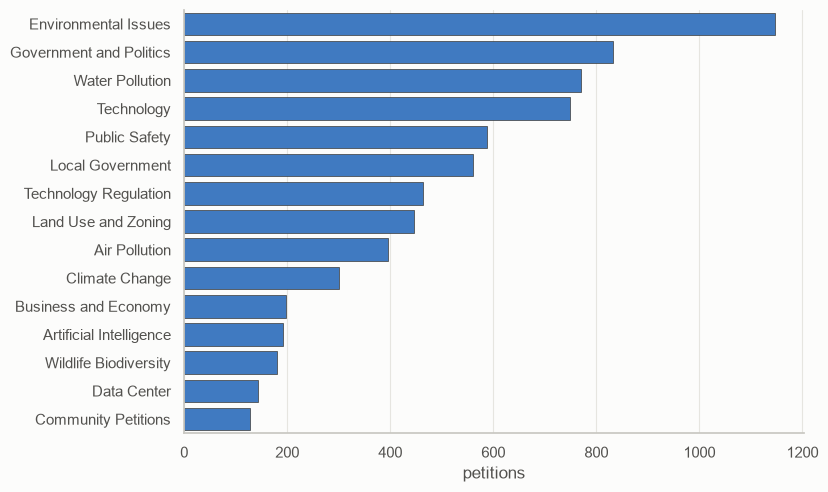

'Environmental Issues' appears on 91% of petitions


In [4]:
tags = pl.read_parquet(DATA / "tutorial_petition_tags.parquet")
top = (tags.group_by("tag").len().rename({"len": "petitions"})
       .sort("petitions", descending=True).head(15))
share = top["petitions"][0] / petitions.height

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.barplot(top.to_pandas(), y="tag", x="petitions", color=S1, order=top["tag"].to_list(),
            edgecolor="#3a3a37", linewidth=0.5, ax=ax)
ax.set_xlabel("petitions"); ax.set_ylabel("")
sns.despine(ax=ax); plt.show()
print(f"'Environmental Issues' appears on {share:.0%} of petitions")

Environmental framing dominates, followed by governance, pollution, and technology. Near-duplicate
tags exist (for example `Data Center` vs `Data Centers`), so treat counts as approximate.

### Signatures vs comments

Both are right-skewed, so we use log scales and a rank (Spearman) correlation.

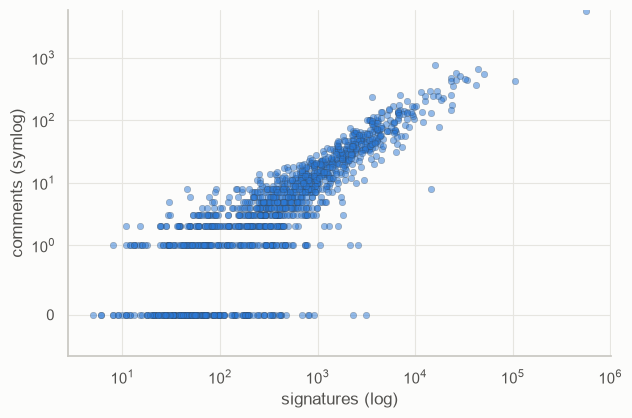

Spearman rho = 0.89


In [5]:
from scipy.stats import spearmanr

d = petitions.filter(pl.col("signatures_total") > 0)
rho, _ = spearmanr(d["signatures_total"], d["comment_total"])

fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(d.to_pandas(), x="signatures_total", y="comment_total", color=S1,
                s=22, alpha=0.5, edgecolor="#3a3a37", linewidth=0.3, ax=ax)
ax.set_xscale("log"); ax.set_yscale("symlog", linthresh=1); ax.set_ylim(bottom=-0.6)
ax.set_xlabel("signatures (log)"); ax.set_ylabel("comments (symlog)")
sns.despine(ax=ax); plt.show()
print(f"Spearman rho = {rho:.2f}")

Signatures and comments rise together closely.

### Petitions and signatures over time

New petitions per quarter, and the total signatures of petitions created each quarter. The final
quarter is partial (collection cut off mid-quarter), so read its drop as truncation, not decline.

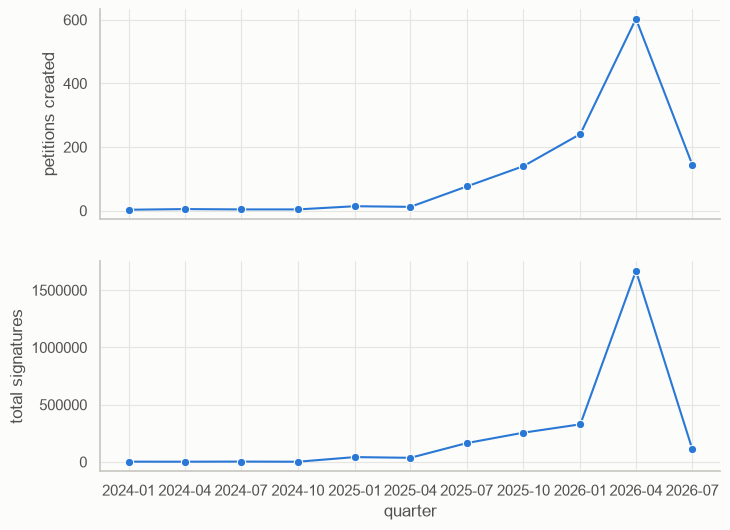

In [6]:
byq = (petitions.group_by(["year", "q"])
       .agg(petitions=pl.len(), signatures=pl.col("signatures_total").sum())
       .with_columns(pl.date(pl.col("year"), (pl.col("q") - 1) * 3 + 1, 1).alias("quarter"))
       .filter(pl.col("year") >= 2024).sort("quarter")).to_pandas()

fig, (a1, a2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)
sns.lineplot(byq, x="quarter", y="petitions", color=S1, marker="o", ax=a1)
a1.set_xlabel(""); a1.set_ylabel("petitions created")
sns.lineplot(byq, x="quarter", y="signatures", color=S1, marker="o", ax=a2)
a2.set_xlabel("quarter"); a2.set_ylabel("total signatures")
a2.ticklabel_format(axis="y", style="plain")
for a in (a1, a2):
    sns.despine(ax=a)
plt.show()

Both climb sharply across 2025 and 2026.

## 4. Link to DCDB site status

DCDB tracks each known data-center site and its lifecycle status (`proposed`, `approved`,
`under_construction`, `operational`, `cancelled`). We match petitions to sites by city/county. A
petition can match several sites, so we keep only petitions whose matched sites share a **single,
unambiguous** status.

In [7]:
link = pl.read_parquet(DATA / "tutorial_petition_sites.parquet")

single = (link.filter(pl.col("lifecycle_status").is_not_null())
          .group_by("petition_id").agg(pl.col("lifecycle_status").unique().alias("s"))
          .filter(pl.col("s").list.len() == 1)
          .with_columns(pl.col("s").list.first().alias("site_status")))
linked = single.join(petitions, on="petition_id", how="inner")

print(linked.height, "petitions with a single site status")
linked.group_by("site_status").agg(
    n=pl.len(),
    median_signatures=pl.col("signatures_total").median(),
    median_comments=pl.col("comment_total").median(),
).sort("median_signatures", descending=True)

181 petitions with a single site status


site_status,n,median_signatures,median_comments
str,u32,f64,f64
"""cancelled""",16,978.0,10.0
"""operational""",16,974.0,11.5
"""approved""",43,930.0,12.0
"""under_construction""",43,651.0,11.0
"""proposed""",63,475.0,6.0


### Does petition activity relate to site status?

Signatures are skewed, so we compare distributions across statuses with a Kruskal-Wallis test and a
boxplot.

Kruskal-Wallis (signatures ~ site status): H=2.29, p=0.68


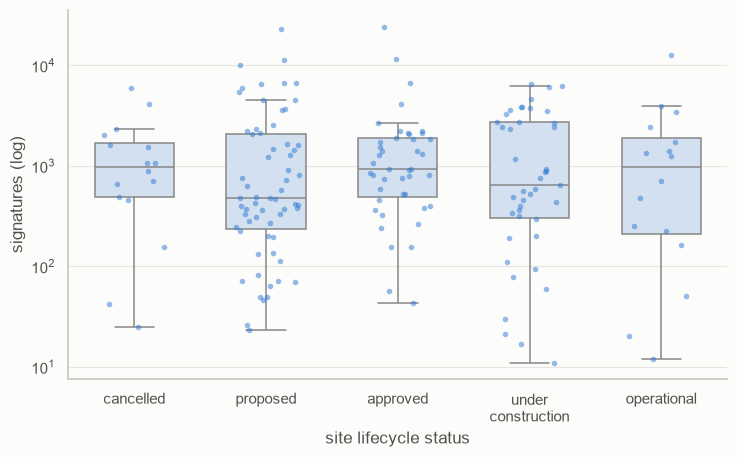

In [8]:
from scipy.stats import kruskal

order = ["cancelled", "proposed", "approved", "under_construction", "operational"]
groups = [linked.filter(pl.col("site_status") == s)["signatures_total"].to_list()
          for s in order if linked.filter(pl.col("site_status") == s).height > 0]
H, p = kruskal(*groups)
print(f"Kruskal-Wallis (signatures ~ site status): H={H:.2f}, p={p:.2f}")

pdl = linked.with_columns(
    pl.col("site_status").str.replace("_", "\n").alias("status")).to_pandas()
order_disp = [s.replace("_", "\n") for s in order]
fig, ax = plt.subplots(figsize=(8.5, 4.8))
sns.boxplot(pdl, x="status", y="signatures_total", order=order_disp, color="#cfe0f3",
            width=0.6, fliersize=0, linewidth=1.1, ax=ax)
sns.stripplot(pdl, x="status", y="signatures_total", order=order_disp, color=S1,
              size=4, alpha=0.5, jitter=0.25, ax=ax)
ax.set_yscale("log"); ax.set_xlabel("site lifecycle status")
ax.set_ylabel("signatures (log)")
sns.despine(ax=ax); plt.show()

The distributions overlap and the test is not significant (p is large): petition signatures do
not relate to a site's status.

## Takeaways

- `petitioner` makes Change.org collection reproducible from **known items + discovered keywords**.
- Data-center petitions **surged through 2025-2026**; signatures and comments track each other closely.
- Petition size **does not predict** a site's DCDB status &mdash; on-platform activity and real-world
  outcomes look decoupled in this data.

Extend this by testing structural predictors (targeted officials, operator, region) or a
multivariate model.